In [1]:
%%capture

!pip install -q gdown albumentations opencv-python pillow pandas scikit-learn tqdm matplotlib

## Import Libraries

In [2]:
import os
import zipfile
import random
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

> Seeding

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

## Import Dataset

- Unzip dataset

In [4]:
file_id = "114xnPVZtthHi4Bejzho33vGJSqb4-F8g"
output_zip = "/content/dataset.zip"
extract_path = Path("/content/flopwd_data")

In [5]:
!gdown --id {file_id} -O {output_zip}

if os.path.exists(output_zip):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Success! Dataset extracted to {extract_path}")
else:
    print("Dataset zip not found.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g
From (redirected): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g&confirm=t&uuid=8220c3ab-dd70-480b-9b40-3e88b04eff95
To: /content/dataset.zip
100% 358M/358M [00:03<00:00, 101MB/s]
Success! Dataset extracted to /content/flopwd_data


- Get Images

In [6]:
dataset_path = extract_path / "Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)"
raw_dir = dataset_path / "Raw_Images"
mask_dir = dataset_path / "Segmentation_Masks"
labels_csv = dataset_path / "Image_labels_Binary Classification Task.csv"
reg_csv = dataset_path / "Mask_foreground_percentages_Regression Task.csv"

raw_images = sorted(list(raw_dir.glob("*")))
mask_images = sorted(list(mask_dir.glob("*")))

print("Raw Images:", len(raw_images))
print("Masks     :", len(mask_images))

Raw Images: 2002
Masks     : 2002


In [7]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [8]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [9]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [10]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(raw_dir / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(mask_dir / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)
df["fg_pct"] = df["fg_pct"].astype(float)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


### EDA Adjustment: Foreground Coverage

In [11]:
def coverage_bin(fg_pct):
    if fg_pct == 0:
        return "zero"
    if fg_pct <= 1:
        return "tiny"
    if fg_pct <= 5:
        return "small"
    if fg_pct <= 25:
        return "medium"
    return "large"


df["coverage_bin"] = df["fg_pct"].apply(coverage_bin)
df["stratify_key"] = df["has_plastic"].astype(str) + "_" + df["coverage_bin"]

print(df["has_plastic"].value_counts().sort_index())
print()
print(df["coverage_bin"].value_counts().sort_index())
print()
print(df["fg_pct"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]))

has_plastic
0     520
1    1482
Name: count, dtype: int64

coverage_bin
large     100
medium    356
small     549
tiny      469
zero      528
Name: count, dtype: int64

count    2002.000000
mean        5.383636
std        12.235488
min         0.000000
5%          0.000000
25%         0.000000
50%         1.020000
75%         4.297500
95%        24.776000
max        81.910000
Name: fg_pct, dtype: float64


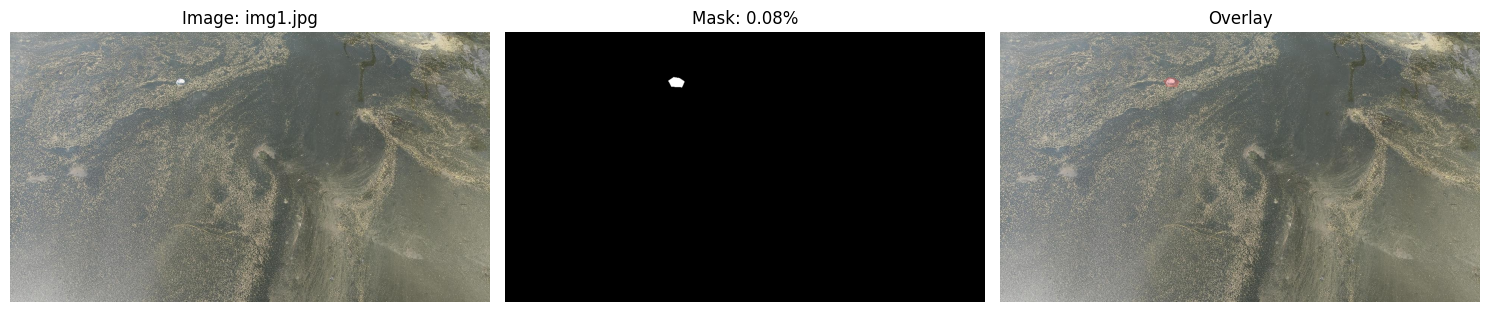

In [12]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
mask = (mask > 127).astype(np.uint8)

overlay = image.copy()
overlay[mask == 1] = (255, 80, 80)
overlay = cv2.addWeighted(image, 0.70, overlay, 0.30, 0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Mask: {row['fg_pct']:.2f}%")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

## Data Splitting (70:15:15)

In [13]:
try:
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=SEED,
        stratify=df["stratify_key"]
    )

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=15 / 85,
        random_state=SEED,
        stratify=train_val_df["stratify_key"]
    )
except ValueError:
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=SEED,
        stratify=df["has_plastic"]
    )

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=15 / 85,
        random_state=SEED,
        stratify=train_val_df["has_plastic"]
    )

In [14]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1400
Val  : 301
Test : 301


In [15]:
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{split_name.upper()}")
    print(split_df["coverage_bin"].value_counts().sort_index())


TRAIN
coverage_bin
large      70
medium    249
small     383
tiny      328
zero      370
Name: count, dtype: int64

VAL
coverage_bin
large     15
medium    53
small     83
tiny      71
zero      79
Name: count, dtype: int64

TEST
coverage_bin
large     15
medium    54
small     83
tiny      70
zero      79
Name: count, dtype: int64


## Data Preprocessing

### Image Augmentation

In [16]:
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 896

In [17]:
def compute_dataset_mean_std(dataframe, sample_size=400):
    sample_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=SEED)
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sum_sq = np.zeros(3, dtype=np.float64)
    pixel_count = 0

    for image_path in tqdm(sample_df["image_path"], desc="Mean/std"):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0

        channel_sum += image.sum(axis=(0, 1))
        channel_sum_sq += (image ** 2).sum(axis=(0, 1))
        pixel_count += image.shape[0] * image.shape[1]

    mean = channel_sum / pixel_count
    std = np.sqrt(channel_sum_sq / pixel_count - mean ** 2)
    return tuple(mean.tolist()), tuple(std.tolist())

In [18]:
mean, std = compute_dataset_mean_std(train_df)
print("Mean:", mean)
print("Std :", std)

Mean/std: 100%|██████████| 400/400 [00:09<00:00, 41.97it/s]

Mean: (0.45198767103254794, 0.46188207529485226, 0.4059114583581686)
Std : (0.172403037735479, 0.1709555012995793, 0.174225197881681)


In [19]:
def make_pad_if_needed():
    try:
        return A.PadIfNeeded(
            min_height=IMAGE_HEIGHT,
            min_width=IMAGE_WIDTH,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
            p=1.0,
        )
    except TypeError:
        return A.PadIfNeeded(
            min_height=IMAGE_HEIGHT,
            min_width=IMAGE_WIDTH,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            mask_value=0,
            p=1.0,
        )

In [20]:
def make_coarse_dropout():
    try:
        return A.CoarseDropout(
            num_holes_range=(1, 6),
            hole_height_range=(16, 48),
            hole_width_range=(16, 48),
            fill=0,
            fill_mask=0,
            p=0.25,
        )
    except TypeError:
        return A.CoarseDropout(
            max_holes=6,
            min_holes=1,
            max_height=48,
            min_height=16,
            max_width=48,
            min_width=16,
            fill_value=0,
            mask_fill_value=0,
            p=0.25,
        )

In [21]:
# transform only training and validation images
train_transform = A.Compose([
    make_pad_if_needed(),
    A.OneOf([
        A.CropNonEmptyMaskIfExists(height=IMAGE_HEIGHT, width=IMAGE_WIDTH, p=1.0),
        A.RandomCrop(height=IMAGE_HEIGHT, width=IMAGE_WIDTH, p=1.0),
    ], p=0.85),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.RandomRotate90(p=0.4),
    A.ShiftScaleRotate(
        shift_limit=0.06,
        scale_limit=0.15,
        rotate_limit=20,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.45,
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1.0),
        A.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.15, hue=0.05, p=1.0),
    ], p=0.45),
    A.GaussNoise(p=0.20),
    A.MotionBlur(blur_limit=3, p=0.12),
    make_coarse_dropout(),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [22]:
val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

### Image Preprocessing (Class & Dataloader)

In [23]:
class FloPWDDataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32)

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.unsqueeze(0)

    return image, mask.float()

In [24]:
train_dataset = FloPWDDataset(train_df, transforms=train_transform)
val_dataset = FloPWDDataset(val_df, transforms=val_transform)
test_dataset = FloPWDDataset(test_df, transforms=val_transform)

In [25]:
BATCH_SIZE = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## Modelling

### COSNet Blocks

In [26]:
class LayerNorm2d(nn.Module):
  def __init__(self, normalized_shape, eps=1e-6):
    super().__init__()
    self.weight = nn.Parameter(torch.ones(normalized_shape))
    self.bias = nn.Parameter(torch.zeros(normalized_shape))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(1, keepdim=True)
    var = (x - mean).pow(2).mean(1, keepdim=True)
    x = (x - mean) / torch.sqrt(var + self.eps)
    x = self.weight[:, None, None] * x + self.bias[:, None, None]
    return x

In [27]:
class MLP(nn.Module):
  def __init__(self, dim, mlp_ratio=4):
    super().__init__()
    hidden_dim = int(dim * mlp_ratio)
    self.fc1 = nn.Conv2d(dim, hidden_dim, kernel_size=1)
    self.pos = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1, groups=hidden_dim)
    self.fc2 = nn.Conv2d(hidden_dim, dim, kernel_size=1)
    self.act = nn.GELU()

  def forward(self, x):
    x = self.fc1(x)
    x = self.act(x)
    x = x + self.act(self.pos(x))
    x = self.fc2(x)
    return x

In [28]:
class MCFS(nn.Module):
  def __init__(self, dim):
    super().__init__()
    group_count = max(1, dim // 4)

    self.proj_1 = nn.Conv2d(dim, dim, kernel_size=1)
    self.norm_proj = LayerNorm2d(dim, eps=1e-6)

    self.s_ctx_1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=group_count)
    self.s_ctx_2 = nn.Conv2d(dim, dim, kernel_size=3, padding=2, dilation=2, groups=group_count)
    self.norm_s = LayerNorm2d(dim, eps=1e-6)

    self.h_ctx = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
    self.norm_h = LayerNorm2d(dim, eps=1e-6)
    self.xw = nn.Conv2d(dim, dim, kernel_size=1)

    self.proj_2 = nn.Conv2d(dim * 2, dim, kernel_size=1)
    self.act = nn.GELU()

  def forward(self, x):
    x = self.norm_proj(self.act(self.proj_1(x)))

    sx = self.s_ctx_1(x) + self.s_ctx_2(x)
    sx = self.norm_s(sx)

    hx = self.h_ctx(x)
    hx = self.norm_h(hx)
    hx_t = hx - hx.mean(dim=1, keepdim=True)
    hx = hx + self.act(self.xw(hx.mean(dim=(2, 3), keepdim=True))) * hx_t

    x = torch.cat([sx, hx], dim=1)
    x = self.act(self.proj_2(x))
    return x

In [29]:
class FSB(nn.Module):
  def __init__(self, dim, mlp_ratio=4):
    super().__init__()
    self.conv_dw = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
    self.norm_dw = LayerNorm2d(dim, eps=1e-6)
    self.norm_1 = LayerNorm2d(dim, eps=1e-6)
    self.norm_2 = LayerNorm2d(dim, eps=1e-6)
    self.attn = MCFS(dim)
    self.mlp = MLP(dim, mlp_ratio=mlp_ratio)

  def forward(self, x):
    x = self.norm_dw(self.conv_dw(x)) + x
    x = x + self.attn(self.norm_1(x))
    x = x + self.mlp(self.norm_2(x))
    return x

In [30]:
class BEM(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.pool = nn.MaxPool2d(kernel_size=4, stride=4)
    self.conv = nn.Sequential(
        nn.Conv2d(dim, dim, kernel_size=3, padding=1),
        LayerNorm2d(dim, eps=1e-6),
        nn.GELU()
    )

  def forward(self, x):
    pooled = self.pool(x)
    pooled = F.interpolate(pooled, size=x.shape[2:], mode="bilinear", align_corners=True)
    boundary = pooled - x
    boundary = self.conv(boundary)
    return boundary

### COSNet Backbone

In [31]:
class StemLayer(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=4)
    self.norm = LayerNorm2d(out_channels, eps=1e-6)

  def forward(self, x):
    x = self.proj(x)
    x = self.norm(x)
    return x

In [32]:
class DownsampleLayer(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.norm = LayerNorm2d(in_channels, eps=1e-6)
    self.reduction = nn.Conv2d(in_channels, out_channels, kernel_size=2, stride=2)

  def forward(self, x):
    x = self.norm(x)
    x = self.reduction(x)
    return x

In [33]:
class COSNetStage(nn.Module):
  def __init__(self, dim, depth):
    super().__init__()
    self.blocks = nn.Sequential(*[FSB(dim) for _ in range(depth)])

  def forward(self, x):
    return self.blocks(x)

In [34]:
class COSNetBackbone(nn.Module):
  def __init__(self, in_channels=3, dims=(64, 128, 320, 512), depths=(3, 3, 9, 3)):
    super().__init__()
    self.stem = StemLayer(in_channels, dims[0])

    self.stage1 = COSNetStage(dims[0], depths[0])
    self.down1 = DownsampleLayer(dims[0], dims[1])

    self.stage2 = COSNetStage(dims[1], depths[1])
    self.down2 = DownsampleLayer(dims[1], dims[2])

    self.stage3 = COSNetStage(dims[2], depths[2])
    self.bem = BEM(dims[2])
    self.down3 = DownsampleLayer(dims[2], dims[3])

    self.stage4 = COSNetStage(dims[3], depths[3])

  def forward(self, x):
    f1 = self.stage1(self.stem(x))
    f2 = self.stage2(self.down1(f1))
    f3 = self.stage3(self.down2(f2))
    f3_boundary = self.bem(f3)
    f4 = self.stage4(self.down3(f3))
    return [f1, f2, f3, f3_boundary, f4]

### UPerNet-style Decoder

In [35]:
class PyramidPoolingModule(nn.Module):
  def __init__(self, in_channels, out_channels, pool_scales=(1, 2, 3, 6)):
    super().__init__()
    self.stages = nn.ModuleList([
        nn.Sequential(
            nn.AdaptiveAvgPool2d(scale),
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            LayerNorm2d(out_channels, eps=1e-6),
            nn.GELU()
        )
        for scale in pool_scales
    ])
    self.bottleneck = nn.Sequential(
        nn.Conv2d(in_channels + len(pool_scales) * out_channels, out_channels, kernel_size=3, padding=1),
        LayerNorm2d(out_channels, eps=1e-6),
        nn.GELU()
    )

  def forward(self, x):
    h, w = x.shape[2:]
    outputs = [x]
    for stage in self.stages:
      pooled = stage(x)
      pooled = F.interpolate(pooled, size=(h, w), mode="bilinear", align_corners=False)
      outputs.append(pooled)
    return self.bottleneck(torch.cat(outputs, dim=1))

In [36]:
class UPerHead(nn.Module):
  def __init__(self, in_channels=(64, 128, 320, 320, 512), channels=256, num_classes=1):
    super().__init__()
    self.ppm = PyramidPoolingModule(in_channels[-1], channels)

    self.lateral_convs = nn.ModuleList([
        nn.Sequential(
            nn.Conv2d(ch, channels, kernel_size=1),
            LayerNorm2d(channels, eps=1e-6),
            nn.GELU()
        )
        for ch in in_channels[:-1]
    ])

    self.fpn_convs = nn.ModuleList([
        nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            LayerNorm2d(channels, eps=1e-6),
            nn.GELU()
        )
        for _ in in_channels[:-1]
    ])

    self.fpn_bottleneck = nn.Sequential(
        nn.Conv2d(len(in_channels) * channels, channels, kernel_size=3, padding=1),
        LayerNorm2d(channels, eps=1e-6),
        nn.GELU()
    )
    self.classifier = nn.Conv2d(channels, num_classes, kernel_size=1)

  def forward(self, inputs, output_size):
    laterals = [conv(inputs[i]) for i, conv in enumerate(self.lateral_convs)]
    laterals.append(self.ppm(inputs[-1]))

    for i in range(len(laterals) - 1, 0, -1):
      laterals[i - 1] = laterals[i - 1] + F.interpolate(
          laterals[i],
          size=laterals[i - 1].shape[2:],
          mode="bilinear",
          align_corners=False
      )

    fpn_outs = [
        self.fpn_convs[i](laterals[i])
        for i in range(len(laterals) - 1)
    ]
    fpn_outs.append(laterals[-1])

    target_size = fpn_outs[0].shape[2:]
    fpn_outs = [
        F.interpolate(out, size=target_size, mode="bilinear", align_corners=False)
        if out.shape[2:] != target_size else out
        for out in fpn_outs
    ]

    x = self.fpn_bottleneck(torch.cat(fpn_outs, dim=1))
    logits = self.classifier(x)
    logits = F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)
    return logits

### COSNet Semantic Segmentation Model

In [37]:
class COSNetForBinarySegmentation(nn.Module):
  def __init__(self):
    super().__init__()
    self.backbone = COSNetBackbone(
        in_channels=3,
        dims=(64, 128, 320, 512),
        depths=(3, 3, 9, 3)
    )
    self.decode_head = UPerHead(
        in_channels=(64, 128, 320, 320, 512),
        channels=256,
        num_classes=1
    )
    self.apply(self._init_weights)

  def _init_weights(self, module):
    if isinstance(module, nn.Conv2d):
      nn.init.trunc_normal_(module.weight, std=0.02)
      if module.bias is not None:
        nn.init.zeros_(module.bias)
    elif isinstance(module, LayerNorm2d):
      nn.init.ones_(module.weight)
      nn.init.zeros_(module.bias)

  def forward(self, x):
    features = self.backbone(x)
    logits = self.decode_head(features, output_size=x.shape[2:])
    return logits

In [38]:
model = COSNetForBinarySegmentation()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 33,377,857


## Training

#### Training Hyperparameter

In [39]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [40]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handling

Give more loss weight when positive plastic pixels are predicted incorrectly.

In [41]:
pos_pixels = 0
neg_pixels = 0

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Counting mask pixels"):
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

raw_pos_weight = neg_pixels / max(pos_pixels, 1)
pos_weight = min(raw_pos_weight, 50.0)

print("Raw pos_weight    :", raw_pos_weight)
print("Clipped pos_weight:", pos_weight)

Counting mask pixels: 100%|██████████| 1400/1400 [00:06<00:00, 209.88it/s]

Raw pos_weight    : 17.273826198356247
Clipped pos_weight: 17.273826198356247


##### BCE Loss Function for Classification per Pixel

In [42]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=DEVICE)
)

##### DICE

Loss function for mask overlapping.

In [43]:
def dice_loss_with_logits(logits, targets, smooth=1.0):
  probs = torch.sigmoid(logits)
  intersection = (probs * targets).sum(dim=(1, 2, 3))
  union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
  dice = (2.0 * intersection + smooth) / (union + smooth)
  return 1.0 - dice.mean()

##### Focal

In [44]:
def focal_loss_with_logits(logits, targets, alpha=0.75, gamma=2.0):
  bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
  probs = torch.sigmoid(logits)
  p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
  alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
  focal = alpha_t * (1.0 - p_t).pow(gamma) * bce
  return focal.mean()

##### Combine

In [45]:
def combined_loss(pred_mask, true_mask, dice_weight=0.45, bce_weight=0.45, focal_weight=0.10):
  d_loss = dice_loss_with_logits(pred_mask, true_mask)
  b_loss = bce_loss(pred_mask, true_mask)
  f_loss = focal_loss_with_logits(pred_mask, true_mask)
  return (dice_weight * d_loss) + (bce_weight * b_loss) + (focal_weight * f_loss)

#### Optimizer

In [46]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=60,
    eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_2276/2643280665.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


#### Metric

In [47]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [48]:
def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()

In [49]:
def compute_confusion_counts(preds, targets):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1, 2, 3))
  fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
  fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))
  tn = ((1 - preds) * (1 - targets)).sum(dim=(1, 2, 3))
  target_pixels = targets.sum(dim=(1, 2, 3))
  pred_pixels = preds.sum(dim=(1, 2, 3))

  return tp, fp, fn, tn, target_pixels, pred_pixels


def summarize_counts(tp, fp, fn, tn, target_pixels, pred_pixels, eps=1e-7):
  tp_total = tp.sum()
  fp_total = fp.sum()
  fn_total = fn.sum()
  tn_total = tn.sum()

  global_foreground_iou = (tp_total + eps) / (tp_total + fp_total + fn_total + eps)
  background_iou = (tn_total + eps) / (tn_total + fp_total + fn_total + eps)
  miou = (global_foreground_iou + background_iou) / 2.0
  global_dice = (2 * tp_total + eps) / (2 * tp_total + fp_total + fn_total + eps)
  precision = (tp_total + eps) / (tp_total + fp_total + eps)
  recall = (tp_total + eps) / (tp_total + fn_total + eps)

  positive_mask = target_pixels > 0
  empty_mask = target_pixels == 0

  if positive_mask.any():
    positive_tp = tp[positive_mask]
    positive_fp = fp[positive_mask]
    positive_fn = fn[positive_mask]
    positive_iou = ((positive_tp + eps) / (positive_tp + positive_fp + positive_fn + eps)).mean()
    positive_dice = ((2 * positive_tp + eps) / (2 * positive_tp + positive_fp + positive_fn + eps)).mean()
  else:
    positive_iou = torch.tensor(0.0, device=tp.device)
    positive_dice = torch.tensor(0.0, device=tp.device)

  if empty_mask.any():
    empty_fp_pixels = pred_pixels[empty_mask].sum()
    empty_total_pixels = (fp[empty_mask] + tn[empty_mask]).sum()
    empty_false_positive_rate = (empty_fp_pixels + eps) / (empty_total_pixels + eps)
    empty_specificity = 1.0 - empty_false_positive_rate
  else:
    empty_false_positive_rate = torch.tensor(0.0, device=tp.device)
    empty_specificity = torch.tensor(1.0, device=tp.device)

  return {
      "iou": global_foreground_iou.item(),
      "foreground_iou": global_foreground_iou.item(),
      "global_foreground_iou": global_foreground_iou.item(),
      "background_iou": background_iou.item(),
      "miou": miou.item(),
      "dice": global_dice.item(),
      "global_dice": global_dice.item(),
      "positive_iou": positive_iou.item(),
      "positive_dice": positive_dice.item(),
      "precision": precision.item(),
      "recall": recall.item(),
      "empty_specificity": empty_specificity.item(),
      "empty_false_positive_rate": empty_false_positive_rate.item(),
      "positive_images": int(positive_mask.sum().item()),
      "empty_images": int(empty_mask.sum().item()),
      "predicted_positive_pixels": int(pred_pixels.sum().item()),
      "actual_positive_pixels": int(target_pixels.sum().item())
  }

In [50]:
def train_one_epoch(model, loader, optimizer, device, grad_accum_steps=2):
  model.train()
  running_loss = 0.0
  optimizer.zero_grad(set_to_none=True)

  pbar = tqdm(loader, desc="Training", leave=False)

  for step, (images, masks) in enumerate(pbar):
    images = images.to(device, non_blocking=True)
    masks = masks.to(device, non_blocking=True)

    with torch.cuda.amp.autocast(enabled=(device == "cuda")):
      logits = model(images)
      loss = combined_loss(logits, masks)
      scaled_loss = loss / grad_accum_steps

    scaler.scale(scaled_loss).backward()

    if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(loader):
      scaler.unscale_(optimizer)
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      scaler.step(optimizer)
      scaler.update()
      optimizer.zero_grad(set_to_none=True)

    running_loss += loss.item()
    pbar.set_postfix(loss=loss.item())

  return running_loss / len(loader)

In [51]:
def validate_one_epoch(model, loader, device, threshold=0.5):
  model.eval()

  running_loss = 0.0
  total_tp = None
  total_fp = None
  total_fn = None
  total_tn = None
  total_target_pixels = None
  total_pred_pixels = None

  with torch.no_grad():
    for images, masks in tqdm(loader, desc="Validation", leave=False):
      images = images.to(device, non_blocking=True)
      masks = masks.to(device, non_blocking=True)

      logits = model(images)
      loss = combined_loss(logits, masks)

      probs = apply_sigmoid(logits)
      preds = binarize_mask(probs, threshold=threshold)
      tp, fp, fn, tn, target_pixels, pred_pixels = compute_confusion_counts(preds, masks)

      running_loss += loss.item()

      if total_tp is None:
        total_tp = tp.cpu()
        total_fp = fp.cpu()
        total_fn = fn.cpu()
        total_tn = tn.cpu()
        total_target_pixels = target_pixels.cpu()
        total_pred_pixels = pred_pixels.cpu()
      else:
        total_tp = torch.cat([total_tp, tp.cpu()])
        total_fp = torch.cat([total_fp, fp.cpu()])
        total_fn = torch.cat([total_fn, fn.cpu()])
        total_tn = torch.cat([total_tn, tn.cpu()])
        total_target_pixels = torch.cat([total_target_pixels, target_pixels.cpu()])
        total_pred_pixels = torch.cat([total_pred_pixels, pred_pixels.cpu()])

  metrics = summarize_counts(
      total_tp,
      total_fp,
      total_fn,
      total_tn,
      total_target_pixels,
      total_pred_pixels
  )
  metrics["loss"] = running_loss / len(loader)
  return metrics

In [52]:
def find_best_threshold(model, loader, device):
  thresholds = np.arange(0.10, 0.91, 0.05)
  best_threshold = 0.5
  best_positive_dice = -1
  best_global_iou = -1

  model.eval()

  all_probs = []
  all_masks = []

  with torch.no_grad():
    for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
      images = images.to(device)
      masks = masks.to(device)

      logits = model(images)
      probs = torch.sigmoid(logits).cpu()

      all_probs.append(probs)
      all_masks.append(masks.cpu().float())

  all_probs = torch.cat(all_probs, dim=0)
  all_masks = torch.cat(all_masks, dim=0)

  for threshold in thresholds:
    preds = (all_probs > threshold).float()
    tp, fp, fn, tn, target_pixels, pred_pixels = compute_confusion_counts(preds, all_masks)
    stats = summarize_counts(tp, fp, fn, tn, target_pixels, pred_pixels)

    improves_positive = stats["positive_dice"] > best_positive_dice
    ties_positive = np.isclose(stats["positive_dice"], best_positive_dice)
    improves_global = stats["global_foreground_iou"] > best_global_iou

    if improves_positive or (ties_positive and improves_global):
      best_positive_dice = stats["positive_dice"]
      best_global_iou = stats["global_foreground_iou"]
      best_threshold = threshold

  return best_threshold, best_positive_dice

#### Training

In [53]:
EPOCHS = 30
PATIENCES = 5
GRAD_ACCUM_STEPS = 2

In [54]:
best_val_positive_dice = -1
best_model_path = "/content/best_flopwd_cosnet_from_scratch.pth"

history = []
counter = 0

In [55]:
for epoch in range(EPOCHS):
  print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

  train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, grad_accum_steps=GRAD_ACCUM_STEPS)

  best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
  val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)
  scheduler.step()

  print(f"Train Loss        : {train_loss:.4f}")
  print(f"Val Loss          : {val_metrics['loss']:.4f}")
  print(f"Val Positive Dice : {val_metrics['positive_dice']:.4f}")
  print(f"Val Positive IoU  : {val_metrics['positive_iou']:.4f}")
  print(f"Val Global FG IoU : {val_metrics['global_foreground_iou']:.4f}")
  print(f"Val Background IoU: {val_metrics['background_iou']:.4f}")
  print(f"Val mIoU          : {val_metrics['miou']:.4f}")
  print(f"Val Global Dice   : {val_metrics['global_dice']:.4f}")
  print(f"Val Precision     : {val_metrics['precision']:.4f}")
  print(f"Val Recall        : {val_metrics['recall']:.4f}")
  print(f"Empty Specificity : {val_metrics['empty_specificity']:.4f}")
  print(f"Empty FP Rate     : {val_metrics['empty_false_positive_rate']:.6f}")
  print(f"Best Threshold    : {best_threshold:.2f}")

  history.append({
      "epoch": epoch + 1,
      "train_loss": train_loss,
      "val_loss": val_metrics["loss"],
      "val_iou": val_metrics["iou"],
      "val_foreground_iou": val_metrics["foreground_iou"],
      "val_global_foreground_iou": val_metrics["global_foreground_iou"],
      "val_background_iou": val_metrics["background_iou"],
      "val_miou": val_metrics["miou"],
      "val_dice": val_metrics["dice"],
      "val_global_dice": val_metrics["global_dice"],
      "val_positive_iou": val_metrics["positive_iou"],
      "val_positive_dice": val_metrics["positive_dice"],
      "val_precision": val_metrics["precision"],
      "val_recall": val_metrics["recall"],
      "val_empty_specificity": val_metrics["empty_specificity"],
      "val_empty_false_positive_rate": val_metrics["empty_false_positive_rate"],
      "val_positive_images": val_metrics["positive_images"],
      "val_empty_images": val_metrics["empty_images"],
      "best_threshold": float(best_threshold)
  })

  if val_metrics["positive_dice"] > best_val_positive_dice:
    best_val_positive_dice = val_metrics["positive_dice"]
    torch.save({
        "model_state_dict": model.state_dict(),
        "best_threshold": float(best_threshold),
        "best_val_positive_dice": float(best_val_positive_dice),
        "epoch": epoch + 1,
        "image_height": IMAGE_HEIGHT,
        "image_width": IMAGE_WIDTH,
        "mean": mean,
        "std": std,
        "pos_weight": float(pos_weight),
        "model_name": "COSNetFromScratch"
    }, best_model_path)
    print("Best model saved.")
    counter = 0
  else:
    counter += 1
    print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

  if counter >= PATIENCES:
    print("Early stopping triggered.")
    break


Epoch [1/30]


Training:   0%|          | 0/700 [00:00<?, ?it/s]/tmp/ipykernel_2276/4164377585.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Train Loss        : 1.0087
Val Loss          : 0.8232
Val Positive Dice : 0.1675
Val Positive IoU  : 0.1117
Val Global FG IoU : 0.1385
Val Background IoU: 0.7147
Val mIoU          : 0.4266
Val Global Dice   : 0.2433
Val Precision     : 0.1427
Val Recall        : 0.8240
Empty Specificity : 0.8469
Empty FP Rate     : 0.153076
Best Threshold    : 0.50
Best model saved.

Epoch [2/30]


Train Loss        : 0.8881
Val Loss          : 0.7809
Val Positive Dice : 0.2410
Val Positive IoU  : 0.1592
Val Global FG IoU : 0.1754
Val Background IoU: 0.8420
Val mIoU          : 0.5087
Val Global Dice   : 0.2985
Val Precision     : 0.1975
Val Recall        : 0.6109
Empty Specificity : 0.8992
Empty FP Rate     : 0.100791
Best Threshold    : 0.65
Best model saved.

Epoch [3/30]


Train Loss        : 0.7895
Val Loss          : 0.6967
Val Positive Dice : 0.3418
Val Positive IoU  : 0.2343
Val Global FG IoU : 0.3529
Val Background IoU: 0.9362
Val mIoU          : 0.6446
Val Global Dice   : 0.5217
Val Precision     : 0.4443
Val Recall        : 0.6318
Empty Specificity : 0.9827
Empty FP Rate     : 0.017258
Best Threshold    : 0.75
Best model saved.

Epoch [4/30]


...

Train Loss        : 0.7059
Val Loss          : 0.6015
Val Positive Dice : 0.4128
Val Positive IoU  : 0.2899
Val Global FG IoU : 0.4343
Val Background IoU: 0.9402
Val mIoU          : 0.6872
Val Global Dice   : 0.6056
Val Precision     : 0.4783
Val Recall        : 0.8253
Empty Specificity : 0.9903
Empty FP Rate     : 0.009690
Best Threshold    : 0.90
No improvement. Patience counter: 1/5

Epoch [8/30]


Train Loss        : 0.6832
Val Loss          : 0.7560
Val Positive Dice : 0.4011
Val Positive IoU  : 0.2813
Val Global FG IoU : 0.4530
Val Background IoU: 0.9579
Val mIoU          : 0.7055
Val Global Dice   : 0.6235
Val Precision     : 0.6149
Val Recall        : 0.6324
Empty Specificity : 0.9965
Empty FP Rate     : 0.003546
Best Threshold    : 0.55
No improvement. Patience counter: 2/5

Epoch [9/30]


Train Loss        : 0.6743
Val Loss          : 0.5946
Val Positive Dice : 0.4123
Val Positive IoU  : 0.2939
Val Global FG IoU : 0.4787
Val Background IoU: 0.9572
Val mIoU          : 0.7179
Val Global Dice   : 0.6474
Val Precision     : 0.5951
Val Recall        : 0.7098
Empty Specificity : 0.9965
Empty FP Rate     : 0.003515
Best Threshold    : 0.90
No improvement. Patience counter: 3/5

Epoch [10/30]


Train Loss        : 0.6393
Val Loss          : 0.5574
Val Positive Dice : 0.4361
Val Positive IoU  : 0.3113
Val Global FG IoU : 0.4700
Val Background IoU: 0.9553
Val mIoU          : 0.7127
Val Global Dice   : 0.6395
Val Precision     : 0.5772
Val Recall        : 0.7167
Empty Specificity : 0.9896
Empty FP Rate     : 0.010400
Best Threshold    : 0.90
No improvement. Patience counter: 4/5

Epoch [11/30]


Train Loss        : 0.6817
Val Loss          : 0.5869
Val Positive Dice : 0.4222
Val Positive IoU  : 0.2999
Val Global FG IoU : 0.4799
Val Background IoU: 0.9596
Val mIoU          : 0.7198
Val Global Dice   : 0.6486
Val Precision     : 0.6245
Val Recall        : 0.6747
Empty Specificity : 0.9965
Empty FP Rate     : 0.003537
Best Threshold    : 0.85
No improvement. Patience counter: 5/5
Early stopping triggered.


##### Training History

In [56]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_cosnet_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_foreground_iou,val_global_foreground_iou,val_background_iou,val_miou,val_dice,val_global_dice,val_positive_iou,val_positive_dice,val_precision,val_recall,val_empty_specificity,val_empty_false_positive_rate,val_positive_images,val_empty_images,best_threshold
6,7,0.705944,0.601525,0.434326,0.434326,0.434326,0.940167,0.687247,0.605617,0.605617,0.289893,0.412839,0.478295,0.825315,0.990310,0.009690,222,79,0.90
7,8,0.683223,0.755977,0.453001,0.453001,0.453001,0.957943,0.705472,0.623539,0.623539,0.281254,0.401131,0.614884,0.632440,0.996454,0.003546,222,79,0.55
8,9,0.674313,0.594624,0.478651,0.478651,0.478651,0.957243,0.717947,0.647416,0.647416,0.293872,0.412340,0.595137,0.709765,0.996485,0.003515,222,79,0.90
9,10,0.639275,0.557395,0.470018,0.470018,0.470018,0.955285,0.712651,0.639472,0.639472,0.311308,0.436110,0.577248,0.716732,0.989600,0.010400,222,79,0.90
10,11,0.681691,0.586929,0.479941,0.479941,0.479941,0.959645,0.719793,0.648594,0.648594,0.299884,0.422242,0.624466,0.674662,0.996463,0.003537,222,79,0.85


##### Best Model

In [57]:
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
best_threshold = checkpoint["best_threshold"]
best_val_positive_dice = checkpoint["best_val_positive_dice"]

##### Best Threshold

In [58]:
best_threshold, best_positive_dice = find_best_threshold(model, val_loader, DEVICE)
print("Best threshold    :", best_threshold)
print("Best Positive Dice:", best_positive_dice)

Best threshold    : 0.9000000000000002
Best Positive Dice: 0.4361834228038788


#### Evaluation

In [59]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
  print(f"{k}: {v:.4f}")

iou: 0.4370
foreground_iou: 0.4370
global_foreground_iou: 0.4370
background_iou: 0.9506
miou: 0.6938
dice: 0.6082
global_dice: 0.6082
positive_iou: 0.2907
positive_dice: 0.4155
precision: 0.5574
recall: 0.6691
empty_specificity: 0.9948
empty_false_positive_rate: 0.0052
positive_images: 222.0000
empty_images: 79.0000
predicted_positive_pixels: 9142230.0000
actual_positive_pixels: 7615963.0000
loss: 0.5856


- Result

In [60]:
with open("/content/flopwd_cosnet_test_metrics.json", "w") as f:
  json.dump(test_metrics, f, indent=4)

##### Regression Percentage

In [61]:
def predict_regression_percentages(model, dataset, dataframe, device, threshold=0.5):
  model.eval()
  rows = []

  with torch.no_grad():
    for idx in tqdm(range(len(dataset)), desc="Regression percentage"):
      image, mask = dataset[idx]
      image_tensor = image.unsqueeze(0).to(device)

      logits = model(image_tensor)
      probs = torch.sigmoid(logits)
      pred = (probs > threshold).float().squeeze().cpu()

      row = dataframe.iloc[idx]
      actual_percentage = float(row["fg_pct"])
      mask_percentage = mask.float().mean().item() * 100.0
      predicted_percentage = pred.float().mean().item() * 100.0

      rows.append({
          "image_name": row["image_name"],
          "actual_regression_percentage": actual_percentage,
          "mask_percentage": mask_percentage,
          "predicted_regression_percentage": predicted_percentage,
          "absolute_error": abs(predicted_percentage - actual_percentage)
      })

  return pd.DataFrame(rows)

In [62]:
regression_df = predict_regression_percentages(
    model,
    test_dataset,
    test_df,
    DEVICE,
    threshold=best_threshold
)

regression_df.to_csv("/content/flopwd_cosnet_regression_percentages.csv", index=False)
regression_df.head()

Regression percentage: 100%|██████████| 301/301 [00:37<00:00,  8.05it/s]


,image_name,actual_regression_percentage,mask_percentage,predicted_regression_percentage,absolute_error
0,img541.jpg,0.00,0.000000,0.337219,0.337219
1,img1432.jpg,63.64,63.646370,74.506271,10.866271
2,img1260.jpg,0.51,0.508554,7.819911,7.309911
3,img282.jpg,0.49,0.573077,0.168065,0.321935
4,img1666.jpg,1.79,1.791600,0.957162,0.832838


## Inferences

In [63]:
def denormalize_image(image_tensor, mean, std):
  image = image_tensor.permute(1, 2, 0).cpu().numpy()
  image = image * np.array(std) + np.array(mean)
  image = np.clip(image, 0, 1)
  return image

In [64]:
def show_predictions(model, dataset, device, threshold=0.5, num_samples=8):
  model.eval()
  indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

  plt.figure(figsize=(16, len(indices) * 4))

  with torch.no_grad():
    for i, idx in enumerate(indices):
      image, mask = dataset[idx]

      input_tensor = image.unsqueeze(0).to(device)
      logits = model(input_tensor)
      probs = torch.sigmoid(logits)
      pred = (probs > threshold).float()

      image_np = denormalize_image(image, mean, std)
      mask_np = mask.squeeze(0).cpu().numpy()
      pred_np = pred.squeeze().cpu().numpy()

      overlay = (image_np * 255).astype(np.uint8)
      overlay_pred = overlay.copy()
      overlay_pred[pred_np == 1] = (255, 80, 80)
      overlay_pred[mask_np == 1] = (80, 255, 80)
      overlay_pred[(mask_np == 1) & (pred_np == 1)] = (255, 220, 60)
      overlay_pred = cv2.addWeighted(overlay, 0.65, overlay_pred, 0.35, 0)

      plt.subplot(len(indices), 4, i * 4 + 1)
      plt.imshow(image_np)
      plt.title("Image")
      plt.axis("off")

      plt.subplot(len(indices), 4, i * 4 + 2)
      plt.imshow(mask_np, cmap="gray")
      plt.title("Ground Truth")
      plt.axis("off")

      plt.subplot(len(indices), 4, i * 4 + 3)
      plt.imshow(pred_np, cmap="gray")
      plt.title("Prediction")
      plt.axis("off")

      plt.subplot(len(indices), 4, i * 4 + 4)
      plt.imshow(overlay_pred)
      plt.title("Overlay")
      plt.axis("off")

  plt.tight_layout()
  plt.show()

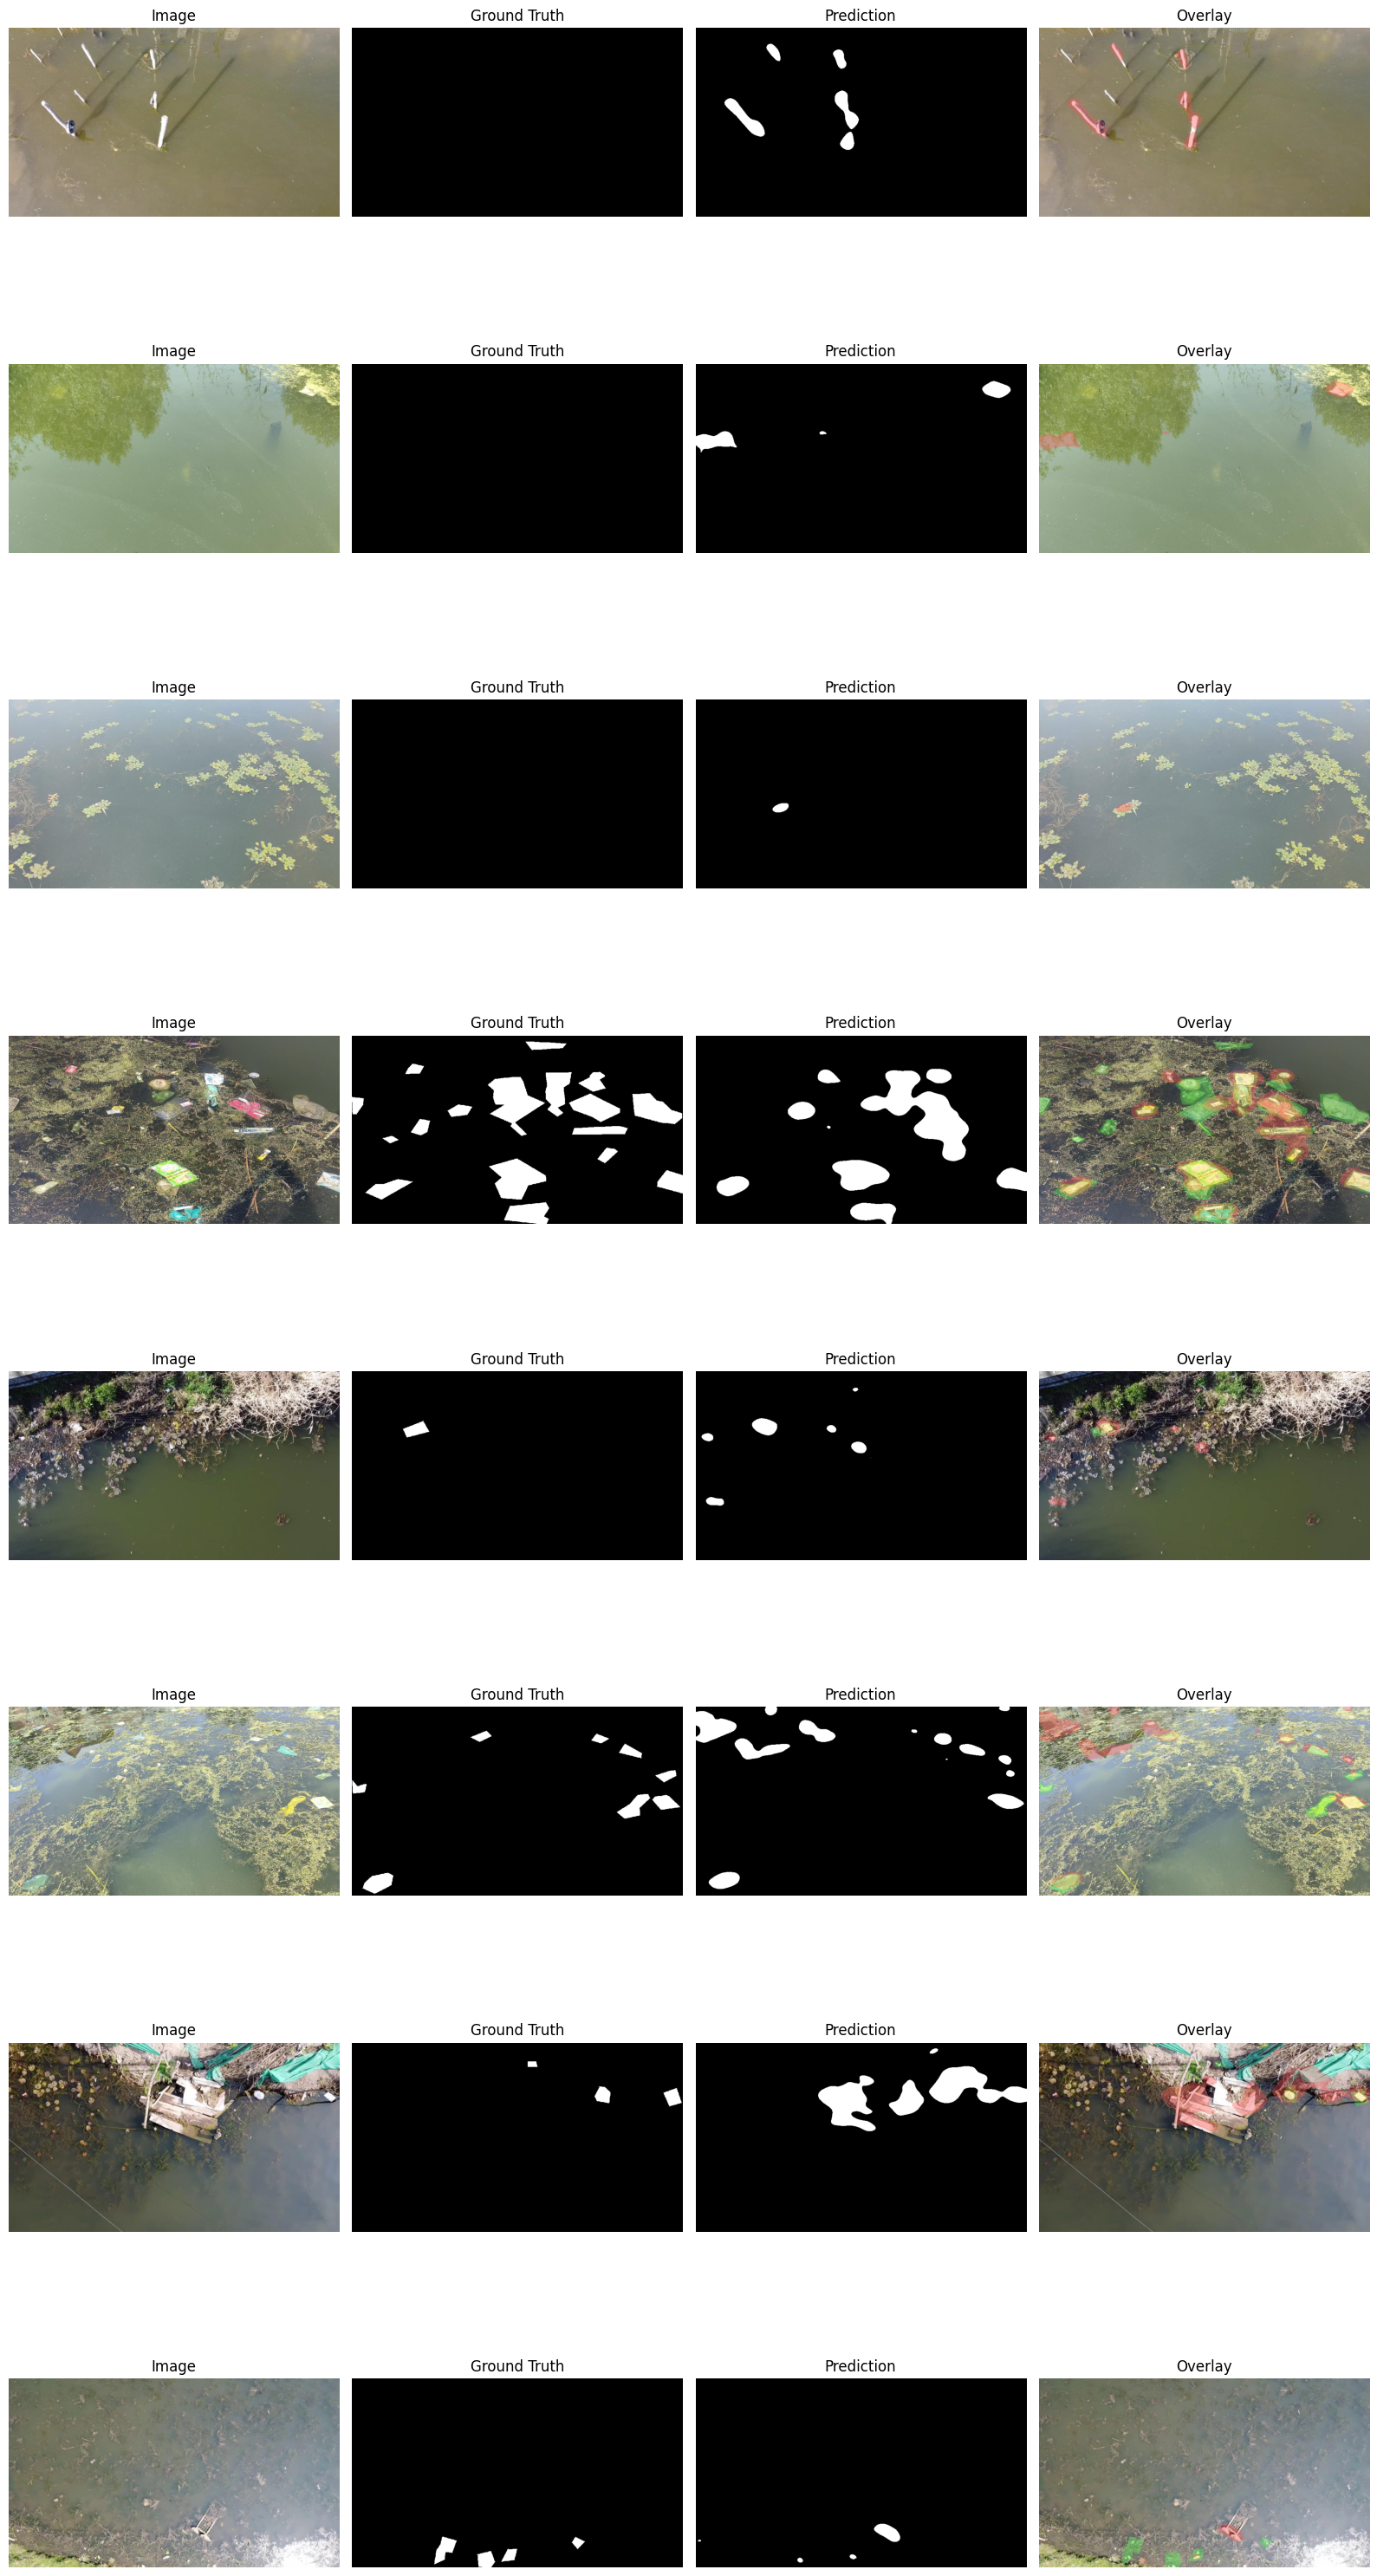

In [65]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=8)